# Proyecto de Aula — Modelos y Simulación II
## Predicción de aprobación de créditos bancarios mediante modelos de aprendizaje automático

**Autores:** David Arango Pineda, Sara Galván Ortega, Juan Pablo Ramos Vélez
**Universidad de Antioquia — Facultad de Ingeniería**

---

Este notebook cubre las **Secciones 4 y 5** de la guía del proyecto:

- **Sección 4 — Entrenamiento y Evaluación de los Modelos (30%)**: configuración experimental, validación cruzada estratificada, ajuste de hiperparámetros y métricas con intervalos de confianza para **7 modelos**.
- **Sección 5 — Reducción de dimensión (20%)**: análisis individual de variables, extracción lineal (PCA) y extracción no lineal (UMAP) reevaluando los 2 mejores modelos.

Los modelos comparados cumplen los tipos exigidos por la guía:

| Tipo exigido (guía) | Modelo usado |
|---|---|
| Paramétrico (regresión) | Regresión Logística |
| No paramétrico | K-Nearest Neighbors (KNN) |
| Ensamble de árboles | Random Forest, XGBoost |
| Red neuronal artificial | MLP (Perceptrón Multicapa) |
| Máquina de vectores de soporte | SVM |
|  Árbol de decisión | Árbol de Decisión |


## 1. Librerías y configuración

In [39]:
!pip install umap-learn xgboost -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             RocCurveDisplay)

from sklearn.decomposition import PCA
import umap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del conjunto de datos

El conjunto de datos corresponde al **Loan Prediction Problem** (Kaggle, dataset de *Debdatta Chatterjee*). El archivo de entrenamiento contiene 614 registros con etiqueta (`Loan_Status`).

> **Nota importante:** el archivo `test.csv` original **no contiene la variable objetivo** (es el conjunto de submission de Kaggle). Por lo tanto, todas las particiones de entrenamiento, validación y test se construyen a partir del archivo de entrenamiento, que es el único con etiquetas. Esto permite medir desempeño real sobre datos no vistos.

La siguiente celda descarga el dataset **automáticamente desde Kaggle** usando `kagglehub` (ya disponible en Google Colab). Si la descarga no es posible, hace *fallback* a un archivo local `train.csv`.

In [40]:
# ============================================================
# CARGA DEL DATASET (local / subida manual en Colab)
# ============================================================
import os
import pandas as pd

# Nombres posibles del archivo de entrenamiento
posibles = ['train.csv', 'train_u6lujuX_CVtuZ9i.csv']

def cargar_dataset():
    # Buscar el archivo en el directorio de trabajo
    for f in posibles:
        if os.path.exists(f):
            print("Datos cargados desde:", f)
            return pd.read_csv(f)
    # Si no está, pedir que lo suban (solo funciona en Colab)
    try:
        from google.colab import files
        print("No encontré el archivo. Súbelo ahora (train.csv)...")
        subidos = files.upload()
        nombre = list(subidos.keys())[0]
        print("Datos cargados desde:", nombre)
        return pd.read_csv(nombre)
    except Exception:
        raise FileNotFoundError(
            "No encontré el archivo de entrenamiento. "
            "Súbelo al entorno (ícono de carpeta 📁 en Colab) y vuelve a ejecutar."
        )

df = cargar_dataset()
print("Shape:", df.shape)
df.head()

Datos cargados desde: train.csv
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [41]:
print('Dimensión del dataset:', df.shape)
df.info()


Dimensión del dataset: (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## 3. Análisis exploratorio (resumen)

Esta sección complementa el EDA de la Sección 2 del informe. Se confirma la presencia de valores faltantes y el desbalance de clases.

In [42]:
# Valores faltantes
faltantes = df.isnull().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print('Valores faltantes por variable:')
print(faltantes)


Valores faltantes por variable:
Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64


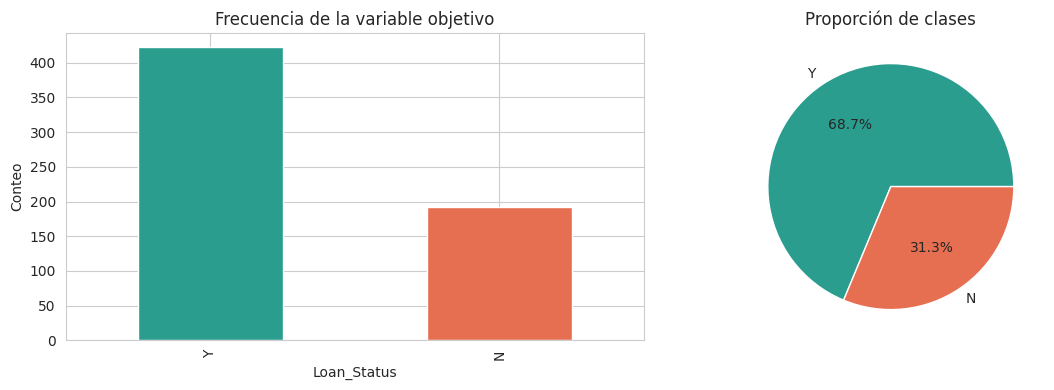


Proporción de clases:
Loan_Status
Y    0.687
N    0.313
Name: proportion, dtype: float64

La clase Y (aprobado) representa ~69% -> dataset DESBALANCEADO.


In [43]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Loan_Status'].value_counts().plot(kind='bar', ax=ax[0], color=['#2a9d8f', '#e76f51'])
ax[0].set_title('Frecuencia de la variable objetivo')
ax[0].set_xlabel('Loan_Status'); ax[0].set_ylabel('Conteo')
df['Loan_Status'].value_counts(normalize=True).plot(kind='pie', ax=ax[1],
        autopct='%1.1f%%', colors=['#2a9d8f', '#e76f51'])
ax[1].set_title('Proporción de clases'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

print('\nProporción de clases:')
print(df['Loan_Status'].value_counts(normalize=True).round(3))
print('\nLa clase Y (aprobado) representa ~69% -> dataset DESBALANCEADO.')


## 4. Preprocesamiento

Pasos aplicados (justificados en la Sección III-B del informe):

1. Se elimina `Loan_ID` (identificador sin valor predictivo).
2. **Imputación**: moda para categóricas, mediana para numéricas.
3. **Codificación**: One-Hot Encoding (`get_dummies`) para categóricas.
4. **Escalamiento**: estandarización de variables numéricas (necesario para SVM, KNN y MLP, sensibles a la magnitud).
5. Codificación de la variable objetivo: `Y -> 1`, `N -> 0`.

> Para evitar **fuga de información (data leakage)**, la imputación y el escalamiento se realizan **dentro de un `Pipeline`**, de modo que los parámetros se ajustan solo con los datos de entrenamiento de cada *fold*.

In [44]:
# Eliminar identificador y separar X / y
df_model = df.drop(columns=['Loan_ID']).copy()

# Codificar objetivo
df_model['Loan_Status'] = df_model['Loan_Status'].map({'Y': 1, 'N': 0})

# 'Dependents' tiene categoría '3+': la tratamos como categórica
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Variables categóricas:', cat_cols)
print('Variables numéricas:  ', num_cols)


Variables categóricas: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Variables numéricas:   ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [45]:
# Imputación + One-Hot para categóricas; imputación mediana para numéricas.
# El escalado se aplica luego sobre la matriz ya codificada, dentro del pipeline de cada modelo.

# Imputamos primero (fuera del pipeline solo para inspección y para PCA/UMAP posteriores),
# pero los modelos usarán un pipeline completo para validación cruzada sin leakage.

# --- Matriz preprocesada de referencia (para análisis individual, PCA y UMAP) ---
X_cat = X[cat_cols].apply(lambda c: c.fillna(c.mode()[0]))
X_cat = pd.get_dummies(X_cat, drop_first=True)

X_num = X[num_cols].apply(lambda c: c.fillna(c.median()))

X_proc = pd.concat([X_num, X_cat], axis=1).astype(float)
print('Dimensión tras codificación:', X_proc.shape)
X_proc.head()


Dimensión tras codificación: (614, 14)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849.0,0.0,128.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3000.0,0.0,66.0,360.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,6000.0,0.0,141.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### 4.1. Configuración experimental

- **Partición**: 80% desarrollo / 20% test, **estratificada** para preservar la proporción de clases.
- **Validación**: `StratifiedKFold` con 10 pliegues sobre el conjunto de desarrollo para el ajuste de hiperparámetros (GridSearchCV).
- **Desbalance**: se usa `class_weight='balanced'` (o `scale_pos_weight` en XGBoost) para reducir el sesgo hacia la clase mayoritaria, evitando depender de sobremuestreo.
- **Métrica principal de optimización**: **F1**, adecuada ante desbalance. Se reportan además Accuracy, Precision, Recall y AUC-ROC.
- **Intervalos de confianza**: estimados sobre los 10 *folds* de la validación cruzada (IC 95% ≈ media ± 1.96·sd/√k).

In [46]:
# Pipeline de preprocesamiento reutilizable (sin leakage): imputación + escalado
# Para categóricas, ya están codificadas en X_proc; aquí construimos un transformer
# que se ajusta dentro de la CV. Trabajaremos sobre X_proc (numérica) escalando todo.

preprocesador = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # por robustez (X_proc ya viene imputada)
    ('scaler', StandardScaler())
])

# Partición estratificada desarrollo/test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_proc, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print('Desarrollo:', X_dev.shape, ' Test:', X_test.shape)
print('Proporción clase positiva  -> dev:', round(y_dev.mean(),3),
      '| test:', round(y_test.mean(),3))

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


Desarrollo: (491, 14)  Test: (123, 14)
Proporción clase positiva  -> dev: 0.686 | test: 0.691


### 4.2. Funciones auxiliares de evaluación

`evaluar_cv` ejecuta validación cruzada para todas las métricas y devuelve media e intervalo de confianza. `evaluar_test` calcula las métricas sobre el conjunto de test retenido.

In [47]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

def ic95(scores):
    """Intervalo de confianza 95% sobre los folds."""
    m = np.mean(scores); s = np.std(scores, ddof=1); n = len(scores)
    h = 1.96 * s / np.sqrt(n)
    return m, h

def evaluar_cv(nombre, pipeline, X, y, cv):
    """Validación cruzada con todas las métricas + IC95 + train scores."""
    res = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                         return_train_score=True, n_jobs=-1)
    fila = {'Modelo': nombre}
    for met in scoring:
        m, h = ic95(res[f'test_{met}'])
        fila[met] = m
        fila[f'{met}_ic'] = h
    fila['f1_train'] = np.mean(res['train_f1'])
    return fila, res

def evaluar_test(nombre, modelo, Xtr, ytr, Xte, yte):
    """Entrena en desarrollo y evalúa en test retenido."""
    modelo.fit(Xtr, ytr)
    yp = modelo.predict(Xte)
    try:
        yproba = modelo.predict_proba(Xte)[:, 1]
    except Exception:
        yproba = modelo.decision_function(Xte)
    return {
        'Modelo': nombre,
        'accuracy': accuracy_score(yte, yp),
        'precision': precision_score(yte, yp),
        'recall': recall_score(yte, yp),
        'f1': f1_score(yte, yp),
        'roc_auc': roc_auc_score(yte, yproba)
    }, yp, yproba

resultados_cv = []     # acumula resultados de validación cruzada
resultados_test = []   # acumula resultados en test
mejores_modelos = {}   # guarda el mejor estimador por modelo
print('Funciones de evaluación listas.')


Funciones de evaluación listas.


## 4.3. Modelo 1 — Regresión Logística (paramétrico)

Modelo lineal interpretable. Se ajusta el hiperparámetro de regularización `C`.

| Hiperparámetro | Malla de valores |
|---|---|
| `C` | 0.01, 0.1, 0.5, 1, 5, 10 |
| `class_weight` | `balanced` (fijo, por desbalance) |

In [48]:
pipe_lr = Pipeline([('prep', preprocesador),
                    ('clf', LogisticRegression(max_iter=1000,
                            class_weight='balanced', random_state=RANDOM_STATE))])

grid_lr = {'clf__C': [0.01, 0.1, 0.5, 1, 5, 10]}

gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=cv, scoring='f1',
                     return_train_score=True, n_jobs=-1)
gs_lr.fit(X_dev, y_dev)
print('Mejor C:', gs_lr.best_params_)
print('Mejor F1 (CV):', round(gs_lr.best_score_, 4))
mejores_modelos['Regresión Logística'] = gs_lr.best_estimator_


Mejor C: {'clf__C': 0.01}
Mejor F1 (CV): 0.8316


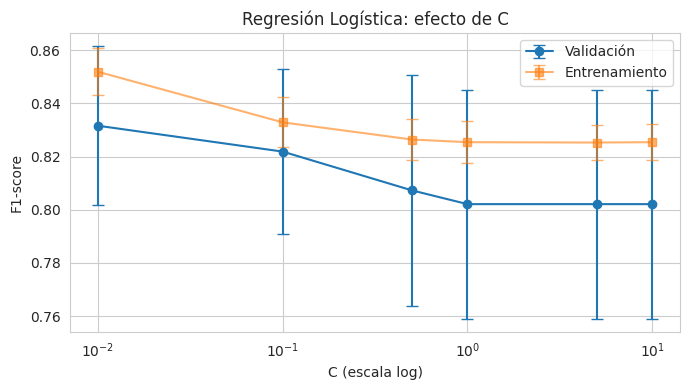

In [49]:
# Efecto del hiperparámetro C
r = pd.DataFrame(gs_lr.cv_results_)
plt.figure(figsize=(7,4))
plt.errorbar(grid_lr['clf__C'], r['mean_test_score'], yerr=r['std_test_score'],
             marker='o', capsize=4, label='Validación')
plt.errorbar(grid_lr['clf__C'], r['mean_train_score'], yerr=r['std_train_score'],
             marker='s', capsize=4, label='Entrenamiento', alpha=0.6)
plt.xscale('log'); plt.xlabel('C (escala log)'); plt.ylabel('F1-score')
plt.title('Regresión Logística: efecto de C'); plt.legend(); plt.tight_layout(); plt.show()
#El mejor desempeño en validación se obtiene con C = 0.01 (F1 ≈ 0.83), disminuyendo ligeramente al aumentar C.
#La cercanía entre las curvas de entrenamiento y validación indica ausencia de sobreajuste, sugiriendo que una
#mayor regularización favorece la generalización en este conjunto de datos

In [50]:
fila, _ = evaluar_cv('Regresión Logística', gs_lr.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Regresión Logística', gs_lr.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8316 ± 0.0195
Test F1: 0.8927


## 4.4. Modelo 2 — K-Nearest Neighbors (no paramétrico)

Clasificador basado en distancias; sensible al escalamiento (ya resuelto en el pipeline).

| Hiperparámetro | Malla |
|---|---|
| `n_neighbors` | 3, 5, 7, 9, 11, 15, 21 |
| `weights` | uniform, distance |

In [51]:
pipe_knn = Pipeline([('prep', preprocesador),
                     ('clf', KNeighborsClassifier())])
grid_knn = {'clf__n_neighbors': [3,5,7,9,11,15,21],
            'clf__weights': ['uniform','distance']}
gs_knn = GridSearchCV(pipe_knn, grid_knn, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_knn.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_knn.best_params_)
print('Mejor F1 (CV):', round(gs_knn.best_score_, 4))
mejores_modelos['KNN'] = gs_knn.best_estimator_


Mejores parámetros: {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
Mejor F1 (CV): 0.856


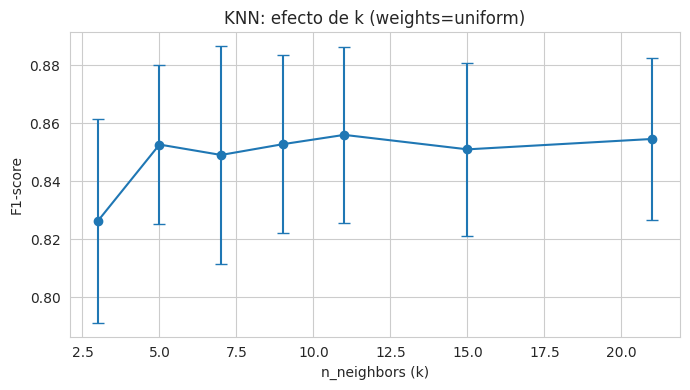

In [52]:
# Efecto de k (con weights=best)
r = pd.DataFrame(gs_knn.cv_results_)
best_w = gs_knn.best_params_['clf__weights']
sub = r[r['param_clf__weights']==best_w]
plt.figure(figsize=(7,4))
plt.errorbar(sub['param_clf__n_neighbors'], sub['mean_test_score'],
             yerr=sub['std_test_score'], marker='o', capsize=4)
plt.xlabel('n_neighbors (k)'); plt.ylabel('F1-score')
plt.title(f'KNN: efecto de k (weights={best_w})'); plt.tight_layout(); plt.show()


In [53]:
fila, _ = evaluar_cv('KNN', gs_knn.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('KNN', gs_knn.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8560 ± 0.0199
Test F1: 0.8889


## 4.5. Modelo 3 — Árbol de Decisión

Modelo interpretable, base de los ensambles. Se controla la profundidad para evitar sobreajuste.

| Hiperparámetro | Malla |
|---|---|
| `max_depth` | 3, 5, 7, 10, None |
| `min_samples_leaf` | 1, 5, 10, 20 |
| `criterion` | gini, entropy |

In [54]:
pipe_dt = Pipeline([('prep', preprocesador),
                    ('clf', DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=RANDOM_STATE))])
grid_dt = {'clf__max_depth': [3,5,7,10,None],
           'clf__min_samples_leaf': [1,5,10,20],
           'clf__criterion': ['gini','entropy']}
gs_dt = GridSearchCV(pipe_dt, grid_dt, cv=cv, scoring='f1',
                     return_train_score=True, n_jobs=-1)
gs_dt.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_dt.best_params_)
print('Mejor F1 (CV):', round(gs_dt.best_score_, 4))
mejores_modelos['Árbol de Decisión'] = gs_dt.best_estimator_


Mejores parámetros: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 5}
Mejor F1 (CV): 0.8326


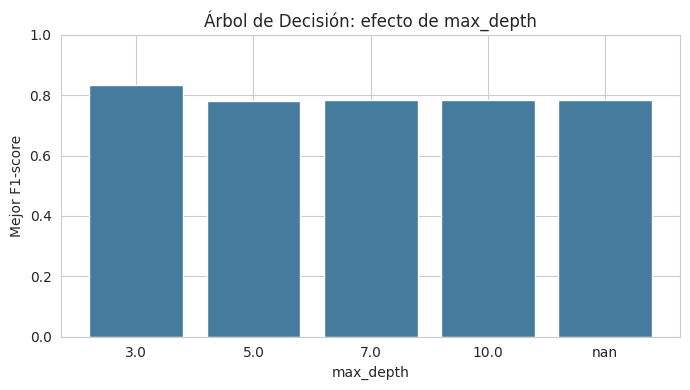

In [55]:
# Efecto de max_depth
r = pd.DataFrame(gs_dt.cv_results_)
agg = r.groupby('param_clf__max_depth', dropna=False)['mean_test_score'].max()
plt.figure(figsize=(7,4))
plt.bar([str(x) for x in agg.index], agg.values, color='#457b9d')
plt.xlabel('max_depth'); plt.ylabel('Mejor F1-score'); plt.ylim(0,1)
plt.title('Árbol de Decisión: efecto de max_depth'); plt.tight_layout(); plt.show()


In [56]:
fila, _ = evaluar_cv('Árbol de Decisión', gs_dt.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Árbol de Decisión', gs_dt.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8326 ± 0.0378
Test F1: 0.8372


## 4.6. Modelo 4 — Random Forest (ensamble de árboles)

Ensamble por *bagging*. Robusto y con baja varianza.

| Hiperparámetro | Malla |
|---|---|
| `n_estimators` | 100, 200, 300 |
| `max_depth` | 5, 10, None |
| `min_samples_leaf` | 1, 5, 10 |

In [57]:
pipe_rf = Pipeline([('prep', preprocesador),
                    ('clf', RandomForestClassifier(class_weight='balanced',
                                                   random_state=RANDOM_STATE))])
grid_rf = {'clf__n_estimators': [100,200,300],
           'clf__max_depth': [5,10,None],
           'clf__min_samples_leaf': [1,5,10]}
gs_rf = GridSearchCV(pipe_rf, grid_rf, cv=cv, scoring='f1',
                     return_train_score=True, n_jobs=-1)
gs_rf.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_rf.best_params_)
print('Mejor F1 (CV):', round(gs_rf.best_score_, 4))
mejores_modelos['Random Forest'] = gs_rf.best_estimator_


Mejores parámetros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
Mejor F1 (CV): 0.8573


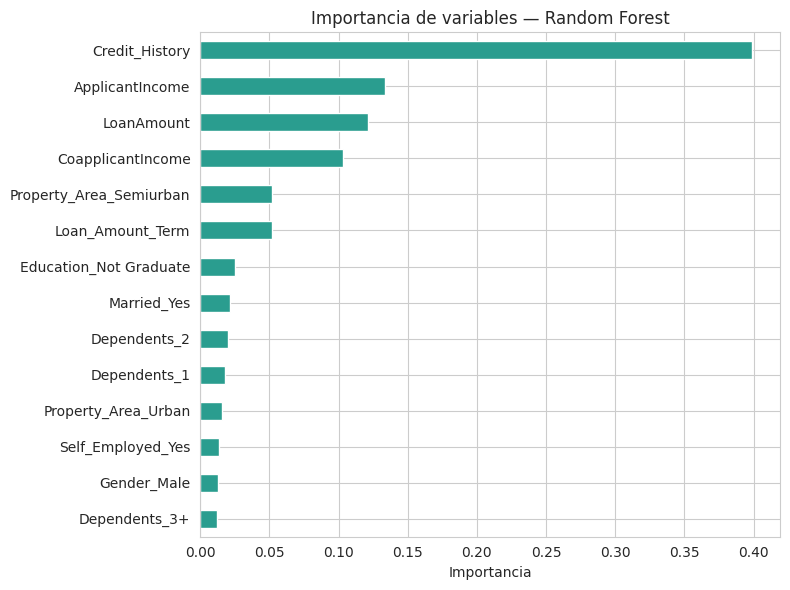

In [58]:
# Importancia de variables del mejor RF
rf_final = gs_rf.best_estimator_.named_steps['clf']
importancias = pd.Series(rf_final.feature_importances_, index=X_proc.columns)
importancias.sort_values().plot(kind='barh', figsize=(8,6), color='#2a9d8f')
plt.title('Importancia de variables — Random Forest'); plt.xlabel('Importancia')
plt.tight_layout(); plt.show()


In [59]:
fila, _ = evaluar_cv('Random Forest', gs_rf.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Random Forest', gs_rf.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8573 ± 0.0189
Test F1: 0.8764


## 4.7. Modelo 5 — XGBoost (ensamble por *boosting*)

Ensamble secuencial de árboles. `scale_pos_weight` maneja el desbalance.

| Hiperparámetro | Malla |
|---|---|
| `n_estimators` | 100, 200 |
| `max_depth` | 3, 5, 7 |
| `learning_rate` | 0.01, 0.1, 0.3 |

In [60]:
spw = (y_dev == 0).sum() / (y_dev == 1).sum()  # razón para desbalance
pipe_xgb = Pipeline([('prep', preprocesador),
                     ('clf', XGBClassifier(scale_pos_weight=spw,
                            eval_metric='logloss', random_state=RANDOM_STATE,
                            use_label_encoder=False))])
grid_xgb = {'clf__n_estimators': [100,200],
            'clf__max_depth': [3,5,7],
            'clf__learning_rate': [0.01,0.1,0.3]}
gs_xgb = GridSearchCV(pipe_xgb, grid_xgb, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_xgb.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_xgb.best_params_)
print('Mejor F1 (CV):', round(gs_xgb.best_score_, 4))
mejores_modelos['XGBoost'] = gs_xgb.best_estimator_


Mejores parámetros: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Mejor F1 (CV): 0.8573


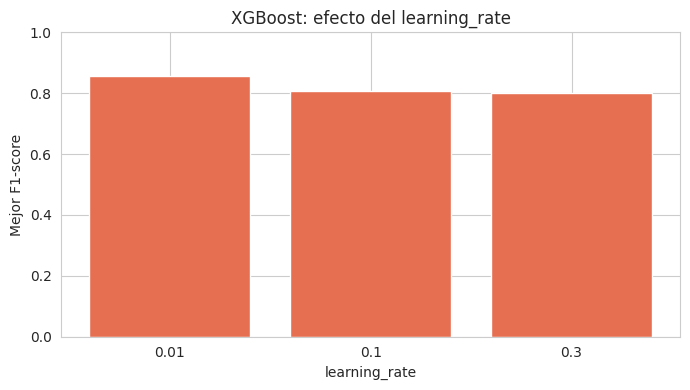

In [61]:
# Efecto del learning_rate
r = pd.DataFrame(gs_xgb.cv_results_)
agg = r.groupby('param_clf__learning_rate')['mean_test_score'].max()
plt.figure(figsize=(7,4))
plt.bar([str(x) for x in agg.index], agg.values, color='#e76f51')
plt.xlabel('learning_rate'); plt.ylabel('Mejor F1-score'); plt.ylim(0,1)
plt.title('XGBoost: efecto del learning_rate'); plt.tight_layout(); plt.show()


In [62]:
fila, _ = evaluar_cv('XGBoost', gs_xgb.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('XGBoost', gs_xgb.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8573 ± 0.0169
Test F1: 0.9022


## 4.8. Modelo 6 — Máquina de Vectores de Soporte (SVM)

Se evalúan kernels lineal y RBF (siguiendo el notebook de clase de SVM).

| Hiperparámetro | Malla |
|---|---|
| `C` | 0.1, 1, 10 |
| `kernel` | linear, rbf |
| `gamma` | scale, 0.01, 0.1 |

In [63]:
pipe_svm = Pipeline([('prep', preprocesador),
                     ('clf', SVC(probability=True, class_weight='balanced',
                                 random_state=RANDOM_STATE))])
grid_svm = {'clf__C': [0.1,1,10],
            'clf__kernel': ['linear','rbf'],
            'clf__gamma': ['scale',0.01,0.1]}
gs_svm = GridSearchCV(pipe_svm, grid_svm, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_svm.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_svm.best_params_)
print('Mejor F1 (CV):', round(gs_svm.best_score_, 4))
mejores_modelos['SVM'] = gs_svm.best_estimator_


Mejores parámetros: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Mejor F1 (CV): 0.8704


In [64]:
fila, _ = evaluar_cv('SVM', gs_svm.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('SVM', gs_svm.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8704 ± 0.0195
Test F1: 0.9032


## 4.9. Modelo 7 — Red Neuronal Artificial (MLP)

Perceptrón multicapa (`MLPClassifier`). Cumple el requisito de **red neuronal artificial** de la guía.

| Hiperparámetro | Malla |
|---|---|
| `hidden_layer_sizes` | (32,), (64,), (64,32) |
| `alpha` (regularización L2) | 0.0001, 0.001, 0.01 |
| `activation` | relu |

> **Alternativa en Colab con Keras/TensorFlow:** si prefieres una red con TensorFlow, puedes reemplazar este bloque por un `Sequential` con capas `Dense`. El `MLPClassifier` se usa aquí por ser reproducible y suficiente para el tamaño del dataset (614 registros).

In [65]:
pipe_mlp = Pipeline([('prep', preprocesador),
                     ('clf', MLPClassifier(max_iter=2000, early_stopping=True,
                                           random_state=RANDOM_STATE))])
grid_mlp = {'clf__hidden_layer_sizes': [(32,),(64,),(64,32)],
            'clf__alpha': [0.0001,0.001,0.01],
            'clf__activation': ['relu']}
gs_mlp = GridSearchCV(pipe_mlp, grid_mlp, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_mlp.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_mlp.best_params_)
print('Mejor F1 (CV):', round(gs_mlp.best_score_, 4))
mejores_modelos['Red Neuronal (MLP)'] = gs_mlp.best_estimator_


Mejores parámetros: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32)}
Mejor F1 (CV): 0.8499


In [66]:
fila, _ = evaluar_cv('Red Neuronal (MLP)', gs_mlp.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Red Neuronal (MLP)', gs_mlp.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8499 ± 0.0228
Test F1: 0.8936


## 4.10. Comparación global de modelos

Se presentan los resultados de **validación cruzada** (con intervalos de confianza del 95%) y de **test** retenido para los 7 modelos.

In [67]:
# Tabla de validación cruzada con IC95
df_cv = pd.DataFrame(resultados_cv)
cols_show = ['Modelo','accuracy','precision','recall','f1','roc_auc']
df_cv_fmt = df_cv.copy()
for met in ['accuracy','precision','recall','f1','roc_auc']:
    df_cv_fmt[met] = df_cv.apply(lambda r: f"{r[met]:.3f} ± {r[met+'_ic']:.3f}", axis=1)
print('=== RESULTADOS DE VALIDACIÓN CRUZADA (media ± IC95%) ===')
df_cv_fmt[cols_show].sort_values('Modelo')


=== RESULTADOS DE VALIDACIÓN CRUZADA (media ± IC95%) ===


,Modelo,accuracy,precision,recall,f1,roc_auc
1,KNN,0.774 ± 0.033,0.763 ± 0.025,0.976 ± 0.019,0.856 ± 0.020,0.688 ± 0.067
3,Random Forest,0.782 ± 0.032,0.783 ± 0.027,0.950 ± 0.019,0.857 ± 0.019,0.744 ± 0.063
6,Red Neuronal (MLP),0.764 ± 0.038,0.757 ± 0.031,0.970 ± 0.019,0.850 ± 0.023,0.691 ± 0.077
0,Regresión Logística,0.752 ± 0.030,0.781 ± 0.028,0.893 ± 0.032,0.832 ± 0.019,0.737 ± 0.074
5,SVM,0.798 ± 0.033,0.782 ± 0.027,0.982 ± 0.016,0.870 ± 0.019,0.708 ± 0.068
4,XGBoost,0.782 ± 0.029,0.783 ± 0.026,0.950 ± 0.017,0.857 ± 0.017,0.736 ± 0.065
2,Árbol de Decisión,0.753 ± 0.045,0.774 ± 0.026,0.908 ± 0.068,0.833 ± 0.038,0.694 ± 0.055


In [80]:
# Tabla de test
df_test = pd.DataFrame(resultados_test).round(3)
print('=== RESULTADOS EN CONJUNTO DE TEST RETENIDO ===')
df_test.sort_values('f1', ascending=False)


=== RESULTADOS EN CONJUNTO DE TEST RETENIDO ===


,Modelo,accuracy,precision,recall,f1,roc_auc
5,SVM,0.854,0.832,0.988,0.903,0.801
4,XGBoost,0.854,0.838,0.976,0.902,0.812
6,Red Neuronal (MLP),0.837,0.816,0.988,0.894,0.794
0,Regresión Logística,0.846,0.859,0.929,0.893,0.840
1,KNN,0.829,0.808,0.988,0.889,0.812
3,Random Forest,0.821,0.839,0.918,0.876,0.814
2,Árbol de Decisión,0.772,0.828,0.847,0.837,0.773


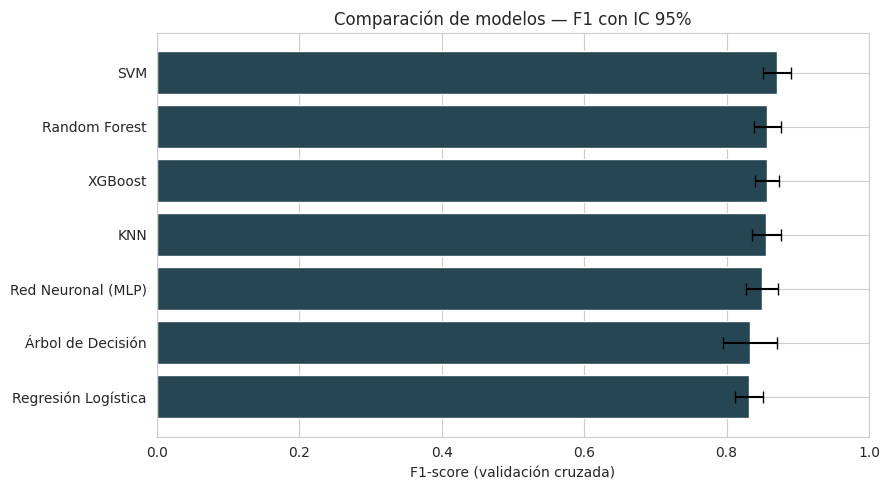

In [81]:
# Gráfico comparativo de F1 (CV) con barras de error
orden = df_cv.sort_values('f1', ascending=False)
plt.figure(figsize=(9,5))
plt.barh(orden['Modelo'], orden['f1'], xerr=orden['f1_ic'],
         capsize=4, color='#264653')
plt.xlabel('F1-score (validación cruzada)'); plt.xlim(0,1)
plt.title('Comparación de modelos — F1 con IC 95%')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()


Dos mejores modelos (por F1 en test): ['SVM', 'XGBoost']


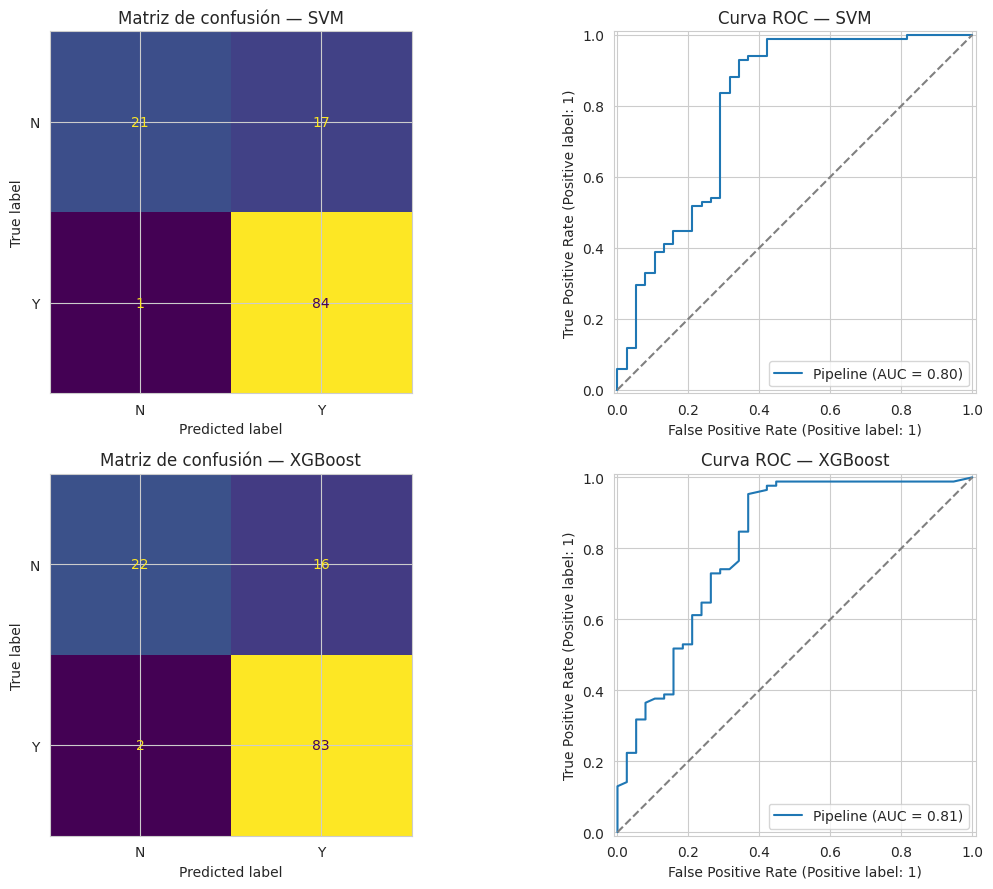

In [82]:
# Matrices de confusión y curvas ROC de los 2 mejores en test
top2 = df_test.sort_values('f1', ascending=False)['Modelo'].head(2).tolist()
print('Dos mejores modelos (por F1 en test):', top2)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for i, nombre in enumerate(top2):
    modelo = mejores_modelos[nombre]
    yp = modelo.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['N','Y']).plot(ax=axes[i,0], colorbar=False)
    axes[i,0].set_title(f'Matriz de confusión — {nombre}')
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=axes[i,1])
    axes[i,1].set_title(f'Curva ROC — {nombre}')
    axes[i,1].plot([0,1],[0,1],'--',color='gray')
plt.tight_layout(); plt.show()


# 5. Reducción de dimensión (20%)

Se evalúa si es posible reducir la complejidad del modelo final mediante:
- **5.1** Análisis individual de variables (correlación / capacidad discriminativa).
- **5.2** Extracción lineal con **PCA**.
- **5.3** Extracción no lineal con **UMAP**.

Las técnicas de extracción se reevalúan sobre los **2 mejores modelos** de la Sección 4.

## 5.1. Análisis individual de variables

Se analiza la correlación de cada variable con la variable objetivo y la correlación entre predictoras, para identificar variables candidatas a eliminar (baja capacidad discriminativa o alta redundancia).

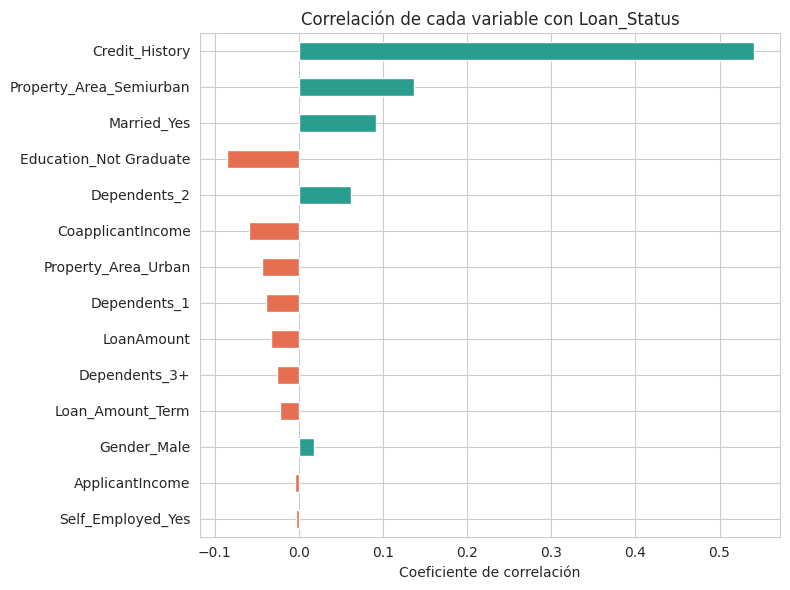

Variables ordenadas por |correlación| con el objetivo:
Credit_History             0.541
Property_Area_Semiurban    0.137
Married_Yes                0.091
Education_Not Graduate     0.086
Dependents_2               0.062
CoapplicantIncome          0.059
Property_Area_Urban        0.044
Dependents_1               0.039
LoanAmount                 0.033
Dependents_3+              0.026
Loan_Amount_Term           0.023
Gender_Male                0.018
ApplicantIncome            0.005
Self_Employed_Yes          0.004
dtype: float64


In [83]:
# Correlación de cada variable con el objetivo
X_full = X_proc.copy()
corr_target = X_full.apply(lambda c: np.corrcoef(c, y)[0,1]).sort_values(key=abs)
plt.figure(figsize=(8,6))
corr_target.plot(kind='barh', color=np.where(corr_target>0,'#2a9d8f','#e76f51'))
plt.title('Correlación de cada variable con Loan_Status')
plt.xlabel('Coeficiente de correlación'); plt.tight_layout(); plt.show()

print('Variables ordenadas por |correlación| con el objetivo:')
print(corr_target.abs().sort_values(ascending=False).round(3))


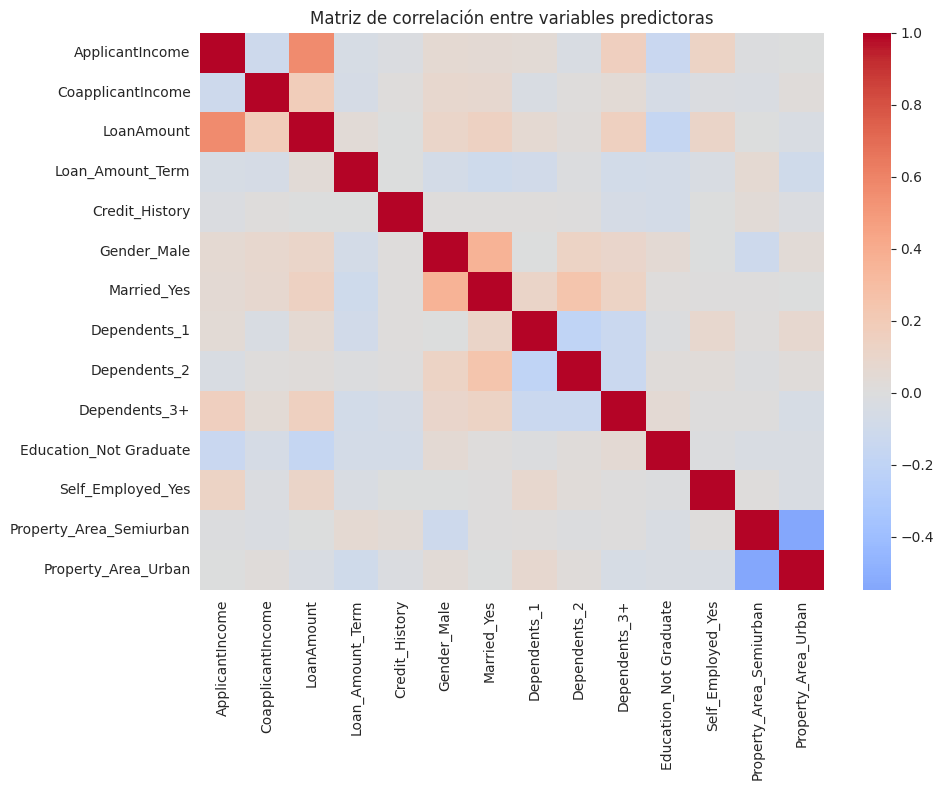

Observación: Credit_History domina la capacidad discriminativa.
Variables con |corr| muy baja con el objetivo son candidatas a eliminación.


In [84]:
# Mapa de calor de correlaciones entre predictoras
plt.figure(figsize=(10,8))
sns.heatmap(X_full.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables predictoras')
plt.tight_layout(); plt.show()

print('Observación: Credit_History domina la capacidad discriminativa.')
print('Variables con |corr| muy baja con el objetivo son candidatas a eliminación.')


**Conclusión 5.1.** La variable `Credit_History` concentra la mayor capacidad discriminativa (correlación ≈ 0.54), muy por encima del resto. A considerable distancia le siguen variables relacionadas con la zona de propiedad (`Property_Area`) y el estado civil. En contraste, variables como Gender, `Self_Employed` y `ApplicantIncome` presentan correlación lineal casi nula con el objetivo, posicionándose como candidatas a eliminación. No obstante, dado que la correlación solo captura relaciones lineales, variables como `ApplicantIncome` —que mostraron importancia en el modelo Random Forest— deben evaluarse con cautela antes de descartarse, pues podrían aportar mediante relaciones no lineales

## 5.2. Extracción de características lineal — PCA

Se aplica PCA sobre las variables escaladas. **Criterio:** seleccionar el número de componentes que explique al menos el **90% de la varianza** acumulada.

Número de variables original: 14
Componentes para >=90% varianza: 11
Reducción: 21.4%


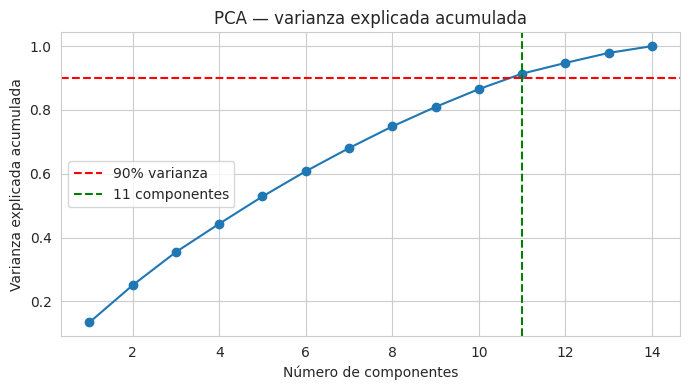

In [73]:
# Escalar toda la matriz de desarrollo y test con el MISMO scaler (ajustado en dev)
scaler_pca = StandardScaler().fit(X_dev)
X_dev_s = scaler_pca.transform(X_dev)
X_test_s = scaler_pca.transform(X_test)

pca_full = PCA().fit(X_dev_s)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(var_acum >= 0.90) + 1)
print(f'Número de variables original: {X_dev.shape[1]}')
print(f'Componentes para >=90% varianza: {n_comp}')
print(f'Reducción: {100*(1 - n_comp/X_dev.shape[1]):.1f}%')

plt.figure(figsize=(7,4))
plt.plot(range(1,len(var_acum)+1), var_acum, marker='o')
plt.axhline(0.90, color='r', ls='--', label='90% varianza')
plt.axvline(n_comp, color='g', ls='--', label=f'{n_comp} componentes')
plt.xlabel('Número de componentes'); plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — varianza explicada acumulada'); plt.legend(); plt.tight_layout(); plt.show()


In [85]:
# Reducción con n_comp y reevaluación de los 2 mejores modelos
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
X_dev_pca = pca.fit_transform(X_dev_s)
X_test_pca = pca.transform(X_test_s)

from sklearn.base import clone
res_pca = []
for nombre in top2:
    # Reconstruimos solo el clasificador (sin el preprocesador, datos ya escalados+PCA)
    clf = clone(mejores_modelos[nombre].named_steps['clf'])
    clf.fit(X_dev_pca, y_dev)
    yp = clf.predict(X_test_pca)
    try: yproba = clf.predict_proba(X_test_pca)[:,1]
    except: yproba = clf.decision_function(X_test_pca)
    res_pca.append({'Modelo': nombre+' + PCA', 'componentes': n_comp,
        'reduccion_%': round(100*(1-n_comp/X_dev.shape[1]),1),
        'accuracy': accuracy_score(y_test,yp),'precision': precision_score(y_test,yp),
        'recall': recall_score(y_test,yp),'f1': f1_score(y_test,yp),
        'roc_auc': roc_auc_score(y_test,yproba)})
df_pca = pd.DataFrame(res_pca).round(3)
print('=== RESULTADOS CON PCA (test) ===')
df_pca


=== RESULTADOS CON PCA (test) ===


,Modelo,componentes,reduccion_%,accuracy,precision,recall,f1,roc_auc
0,SVM + PCA,11,21.4,0.854,0.832,0.988,0.903,0.840
1,XGBoost + PCA,11,21.4,0.821,0.839,0.918,0.876,0.786


## 5.3. Extracción de características no lineal — UMAP

UMAP (Uniform Manifold Approximation and Projection) captura estructura no lineal. **Criterio:** se elige un número reducido de componentes (probando 2 a 5) y se reevalúan los 2 mejores modelos.

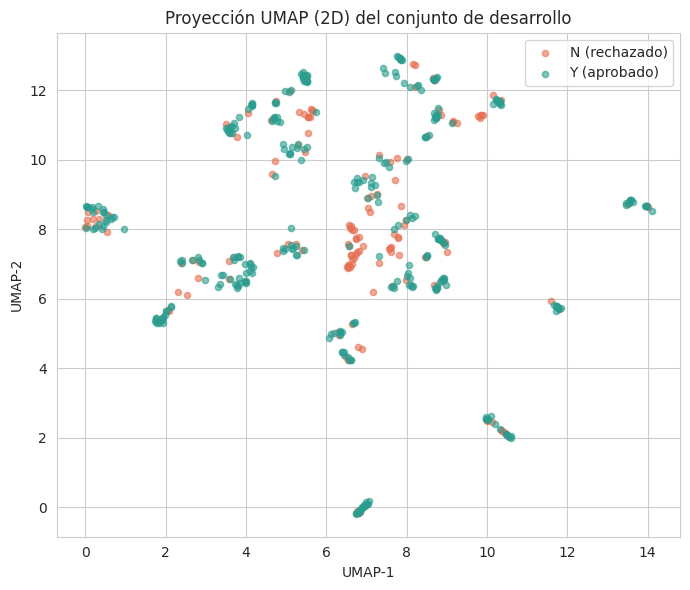

In [86]:
# Visualización UMAP en 2D
reducer_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
emb_2d = reducer_2d.fit_transform(X_dev_s)
plt.figure(figsize=(7,6))
for cl, color, lab in [(0,'#e76f51','N (rechazado)'),(1,'#2a9d8f','Y (aprobado)')]:
    m = y_dev.values==cl
    plt.scatter(emb_2d[m,0], emb_2d[m,1], c=color, label=lab, alpha=0.6, s=20)
plt.legend(); plt.title('Proyección UMAP (2D) del conjunto de desarrollo')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2'); plt.tight_layout(); plt.show()


In [87]:
# Elegir n_components de UMAP por F1 en validación sobre el dev
mejor_n, mejor_f1 = None, -1
for n in [2,3,4,5]:
    red = umap.UMAP(n_components=n, random_state=RANDOM_STATE)
    Xe = red.fit_transform(X_dev_s)
    clf = clone(mejores_modelos[top2[0]].named_steps['clf'])
    f1cv = cross_val_score(clf, Xe, y_dev, cv=cv, scoring='f1', n_jobs=-1).mean()
    print(f'UMAP n_components={n} -> F1 CV={f1cv:.4f}')
    if f1cv > mejor_f1: mejor_f1, mejor_n = f1cv, n
print(f'\nNúmero de componentes UMAP elegido: {mejor_n}')


UMAP n_components=2 -> F1 CV=0.6187
UMAP n_components=3 -> F1 CV=0.5009
UMAP n_components=4 -> F1 CV=0.5209
UMAP n_components=5 -> F1 CV=0.6663

Número de componentes UMAP elegido: 5


In [88]:
# Reducción final con UMAP y reevaluación de los 2 mejores
reducer = umap.UMAP(n_components=mejor_n, random_state=RANDOM_STATE)
X_dev_um = reducer.fit_transform(X_dev_s)
X_test_um = reducer.transform(X_test_s)

res_um = []
for nombre in top2:
    clf = clone(mejores_modelos[nombre].named_steps['clf'])
    clf.fit(X_dev_um, y_dev)
    yp = clf.predict(X_test_um)
    try: yproba = clf.predict_proba(X_test_um)[:,1]
    except: yproba = clf.decision_function(X_test_um)
    res_um.append({'Modelo': nombre+' + UMAP', 'componentes': mejor_n,
        'reduccion_%': round(100*(1-mejor_n/X_dev.shape[1]),1),
        'accuracy': accuracy_score(y_test,yp),'precision': precision_score(y_test,yp),
        'recall': recall_score(y_test,yp),'f1': f1_score(y_test,yp),
        'roc_auc': roc_auc_score(y_test,yproba)})
df_um = pd.DataFrame(res_um).round(3)
print('=== RESULTADOS CON UMAP (test) ===')
df_um


=== RESULTADOS CON UMAP (test) ===


,Modelo,componentes,reduccion_%,accuracy,precision,recall,f1,roc_auc
0,SVM + UMAP,5,64.3,0.528,0.708,0.541,0.613,0.585
1,XGBoost + UMAP,5,64.3,0.699,0.793,0.765,0.778,0.732


## 6. Discusión y conclusiones

Comparación final entre el modelo completo (todas las variables) y las versiones reducidas con PCA y UMAP, para los 2 mejores modelos.

In [89]:
# Tabla comparativa final: original vs PCA vs UMAP
df_orig = pd.DataFrame(resultados_test)
df_orig = df_orig[df_orig['Modelo'].isin(top2)].copy()
df_orig['Modelo'] = df_orig['Modelo'] + ' (original)'
df_orig['componentes'] = X_dev.shape[1]
df_orig['reduccion_%'] = 0.0

comparacion = pd.concat([df_orig, df_pca, df_um], ignore_index=True)
cols = ['Modelo','componentes','reduccion_%','accuracy','precision','recall','f1','roc_auc']
print('=== COMPARACIÓN FINAL: ORIGINAL vs PCA vs UMAP ===')
comparacion[cols].round(3).sort_values('f1', ascending=False)


=== COMPARACIÓN FINAL: ORIGINAL vs PCA vs UMAP ===


,Modelo,componentes,reduccion_%,accuracy,precision,recall,f1,roc_auc
1,SVM (original),14,0.0,0.854,0.832,0.988,0.903,0.801
2,SVM + PCA,11,21.4,0.854,0.832,0.988,0.903,0.840
0,XGBoost (original),14,0.0,0.854,0.838,0.976,0.902,0.812
3,XGBoost + PCA,11,21.4,0.821,0.839,0.918,0.876,0.786
5,XGBoost + UMAP,5,64.3,0.699,0.793,0.765,0.778,0.732
4,SVM + UMAP,5,64.3,0.528,0.708,0.541,0.613,0.585


### Conclusiones

1. **Desempeño de los modelos.** Los siete modelos alcanzaron un desempeño
competitivo y estadísticamente similar (F1 entre 0.83 y 0.90 en test, con
intervalos de confianza solapados), siendo SVM el mejor (F1 = 0.903). El uso
de F1 y AUC-ROC, junto con `class_weight='balanced'`, permitió manejar el
desbalance (~69%/31%) sin sesgar las decisiones hacia la clase mayoritaria.

2. **Variable dominante.** Tres análisis independientes (correlación,
importancia en Random Forest y el comportamiento de los modelos) confirman que
`Credit_History` concentra la mayor capacidad discriminativa, coincidiendo con
la literatura que resalta el historial crediticio (Sheikh et al.).

3. **Reducción de dimensión.** PCA conservó ≥90% de la varianza con 11
componentes (reducción del 21.4%) manteniendo el desempeño del modelo completo
—e incluso mejorando el AUC de SVM (0.801 → 0.840)—. La modesta capacidad de
reducción refleja la baja redundancia entre variables. En contraste, UMAP, pese
a lograr mayor compresión (64.3%), degradó notablemente el desempeño (SVM: 0.903
→ 0.613), indicando que la estructura discriminante del problema es esencialmente
lineal.

4. **Comparación con el estado del arte.** A diferencia de trabajos previos que
reportan a los ensambles (Random Forest, XGBoost) como los mejores clasificadores
(Saha et al., Tumuluru et al.), en este estudio SVM igualó o superó a dichos
modelos, y las diferencias entre todos los clasificadores fueron mínimas. Esto se
atribuye al tamaño reducido del conjunto de datos y al fuerte dominio de una única
variable, factores que nivelan el desempeño entre algoritmos.


In [79]:
# Guardar tablas de resultados a CSV (para incluir en el informe)
df_cv.to_csv('resultados_validacion_cruzada.csv', index=False)
pd.DataFrame(resultados_test).to_csv('resultados_test.csv', index=False)
comparacion[cols].to_csv('resultados_reduccion_dimension.csv', index=False)
print('Resultados exportados: resultados_validacion_cruzada.csv, resultados_test.csv, resultados_reduccion_dimension.csv')


Resultados exportados: resultados_validacion_cruzada.csv, resultados_test.csv, resultados_reduccion_dimension.csv


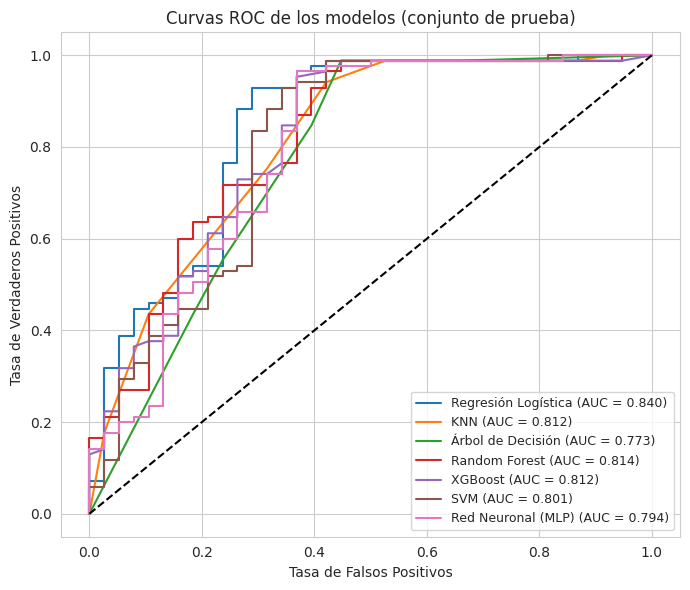

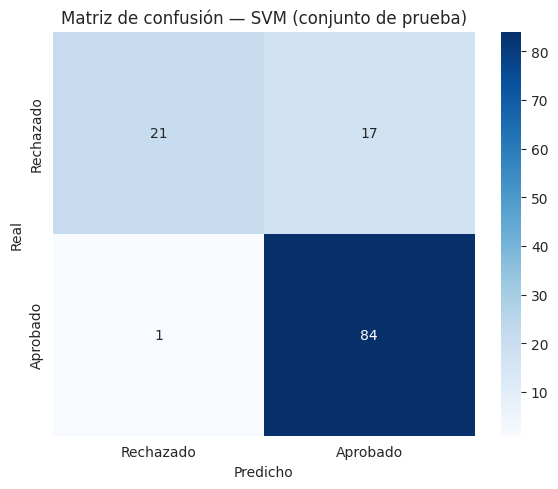

In [90]:
# ========== Curva ROC de todos los modelos + Matriz de confusión ==========
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

# --- ROC con los 7 modelos sobre el test ---
plt.figure(figsize=(7,6))
for nombre, modelo in mejores_modelos.items():
    modelo.fit(X_dev, y_dev)
    try:
        proba = modelo.predict_proba(X_test)[:, 1]
    except Exception:
        proba = modelo.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    a = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {a:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC de los modelos (conjunto de prueba)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# --- Matriz de confusión del mejor modelo (SVM) ---
mejor = mejores_modelos['SVM']
mejor.fit(X_dev, y_dev)
yp = mejor.predict(X_test)
cm = confusion_matrix(y_test, yp)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Rechazado','Aprobado'],
            yticklabels=['Rechazado','Aprobado'])
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title('Matriz de confusión — SVM (conjunto de prueba)')
plt.tight_layout()
plt.show()